In [1]:
# ==================== IMPORT LIBRARIES ====================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("Libraries loaded successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print("="*70)

Libraries loaded successfully!
TensorFlow version: 2.18.0
OpenCV version: 4.12.0


In [2]:
# ==================== LOAD & FILTER DATASET ====================
"""
Scan dataset dan filter hanya Cataract & Normal
"""
print("="*70)
print("LOADING DATASET")
print("="*70)

# Dataset path
data_dir = "dataset" 

def create_dataframe(data_dir, target_classes=['cataract', 'normal']):
    """
    Scan dataset dan ambil hanya Cataract dan Normal
    """
    filepaths = []
    labels = []
    
    print("\nScanning folders...")
    all_folders = os.listdir(data_dir)
    print(f"Found: {all_folders}")
    
    # Filter target folders
    target_folders = [f for f in all_folders 
                      if any(t in f.lower() for t in target_classes)]
    print(f"\n✓ Filtered to: {target_folders}")
    
    # Collect files
    for folder in target_folders:
        folder_path = os.path.join(data_dir, folder)
        if os.path.isdir(folder_path):
            files = [f for f in os.listdir(folder_path) 
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            print(f"  {folder}: {len(files)} images")
            
            for file in files:
                filepaths.append(os.path.join(folder_path, file))
                labels.append('Cataract' if 'cataract' in folder.lower() else 'Normal')
    
    # Create DataFrame
    df = pd.DataFrame({
        'filepaths': filepaths,
        'labels': labels
    })
    
    return df

# Load data
df = create_dataframe(data_dir)

print("\n" + "="*70)
print("DATASET SUMMARY")
print("="*70)
print(f"Total images: {len(df)}")
print(f"\nClass distribution:")
print(df['labels'].value_counts())
print(f"\nBalance ratio: {df['labels'].value_counts().min() / df['labels'].value_counts().max():.2%}")
print("="*70)

LOADING DATASET

Scanning folders...
Found: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

✓ Filtered to: ['cataract', 'normal']
  cataract: 1038 images
  normal: 1074 images

DATASET SUMMARY
Total images: 2112

Class distribution:
labels
Normal      1074
Cataract    1038
Name: count, dtype: int64

Balance ratio: 96.65%


In [6]:
# ==================== SPLIT DATASET ====================

print("="*70)
print("SPLITTING DATASET (70-15-15)")
print("="*70)

# Split 1: 70% train
train_df, temp_df = train_test_split(
    df,
    train_size=0.70,  # 70% untuk training
    shuffle=True,
    random_state=42,
    stratify=df['labels']
)

# Split 2: 50-50 (masing-masing 15% dari total)
val_df, test_df = train_test_split(
    temp_df,
    train_size=0.5,  
    shuffle=True,
    random_state=42,
    stratify=temp_df['labels']
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n📊 SPLIT SUMMARY")
print("="*70)
print(f"Total dataset: {len(df)} images\n")

print(f"Train:      {len(train_df):4d} images ({len(train_df)/len(df)*100:.1f}%)")
print(train_df['labels'].value_counts().to_string())

print(f"\nValidation: {len(val_df):4d} images ({len(val_df)/len(df)*100:.1f}%)")
print(val_df['labels'].value_counts().to_string())

print(f"\nTest:       {len(test_df):4d} images ({len(test_df)/len(df)*100:.1f}%)")
print(test_df['labels'].value_counts().to_string())

# Memastika tidak ada kebocoran data
train_files = set(train_df['filepaths'])
val_files = set(val_df['filepaths'])
test_files = set(test_df['filepaths'])

assert len(train_files.intersection(val_files)) == 0, "❌ Train-Val overlap!"
assert len(train_files.intersection(test_files)) == 0, "❌ Train-Test overlap!"
assert len(val_files.intersection(test_files)) == 0, "❌ Val-Test overlap!"

print("\n Tidak Ada Kebocoran Data!")

# Summary statistics
print("\n" + "="*70)
print("SPLIT STATISTICS")
print("="*70)
print(f"Train samples:      {len(train_df):4d} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation samples: {len(val_df):4d} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test samples:       {len(test_df):4d} ({len(test_df)/len(df)*100:.1f}%)")
print(f"\n Data Siap Di Proses")
print("="*70)

SPLITTING DATASET (70-15-15)

📊 SPLIT SUMMARY
Total dataset: 2112 images

Train:      1478 images (70.0%)
labels
Normal      752
Cataract    726

Validation:  317 images (15.0%)
labels
Normal      161
Cataract    156

Test:        317 images (15.0%)
labels
Normal      161
Cataract    156

 Tidak Ada Kebocoran Data!

SPLIT STATISTICS
Train samples:      1478 (70.0%)
Validation samples:  317 (15.0%)
Test samples:        317 (15.0%)

 Data Siap Di Proses


In [7]:
# ==================== IMAGE PREPROCESSING & AUGMENTATION ====================
"""
Setup data augmentation dan preprocessing untuk training
"""
print("="*70)
print("DATA PREPROCESSING & AUGMENTATION")
print("="*70)

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print(f"\nImage size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

# Data Augmentation for TRAINING only
print("\n📸 Training Augmentation:")
print("  • Rotation: ±5°")
print("  • Width/Height shift: 5%")
print("  • Shear: 5%")
print("  • Zoom: 5%")
print("  • Horizontal flip")
print("  • Brightness: 80-120%")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='constant'
)

# ONLY rescaling for validation & test
print("\n📸 Validation & Test:")
print("  • Only rescale (1/255)")

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
print("\nCreating data generators...")

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n✓ Data generators created successfully!")
print(f"  • Train batches: {len(train_gen)}")
print(f"  • Val batches: {len(val_gen)}")
print(f"  • Test batches: {len(test_gen)}")
print("="*70)

DATA PREPROCESSING & AUGMENTATION

Image size: (224, 224)
Batch size: 32

📸 Training Augmentation:
  • Rotation: ±5°
  • Width/Height shift: 5%
  • Shear: 5%
  • Zoom: 5%
  • Horizontal flip
  • Brightness: 80-120%

📸 Validation & Test:
  • Only rescale (1/255)

Creating data generators...
Found 1478 validated image filenames belonging to 2 classes.
Found 317 validated image filenames belonging to 2 classes.
Found 317 validated image filenames belonging to 2 classes.

✓ Data generators created successfully!
  • Train batches: 47
  • Val batches: 10
  • Test batches: 10


VISUALISASI DATA SETELAH AUGMENTASI

📊 Generating augmentation visualization...
   Showing 3 samples × 5 versions (1 original + 4 augmented)



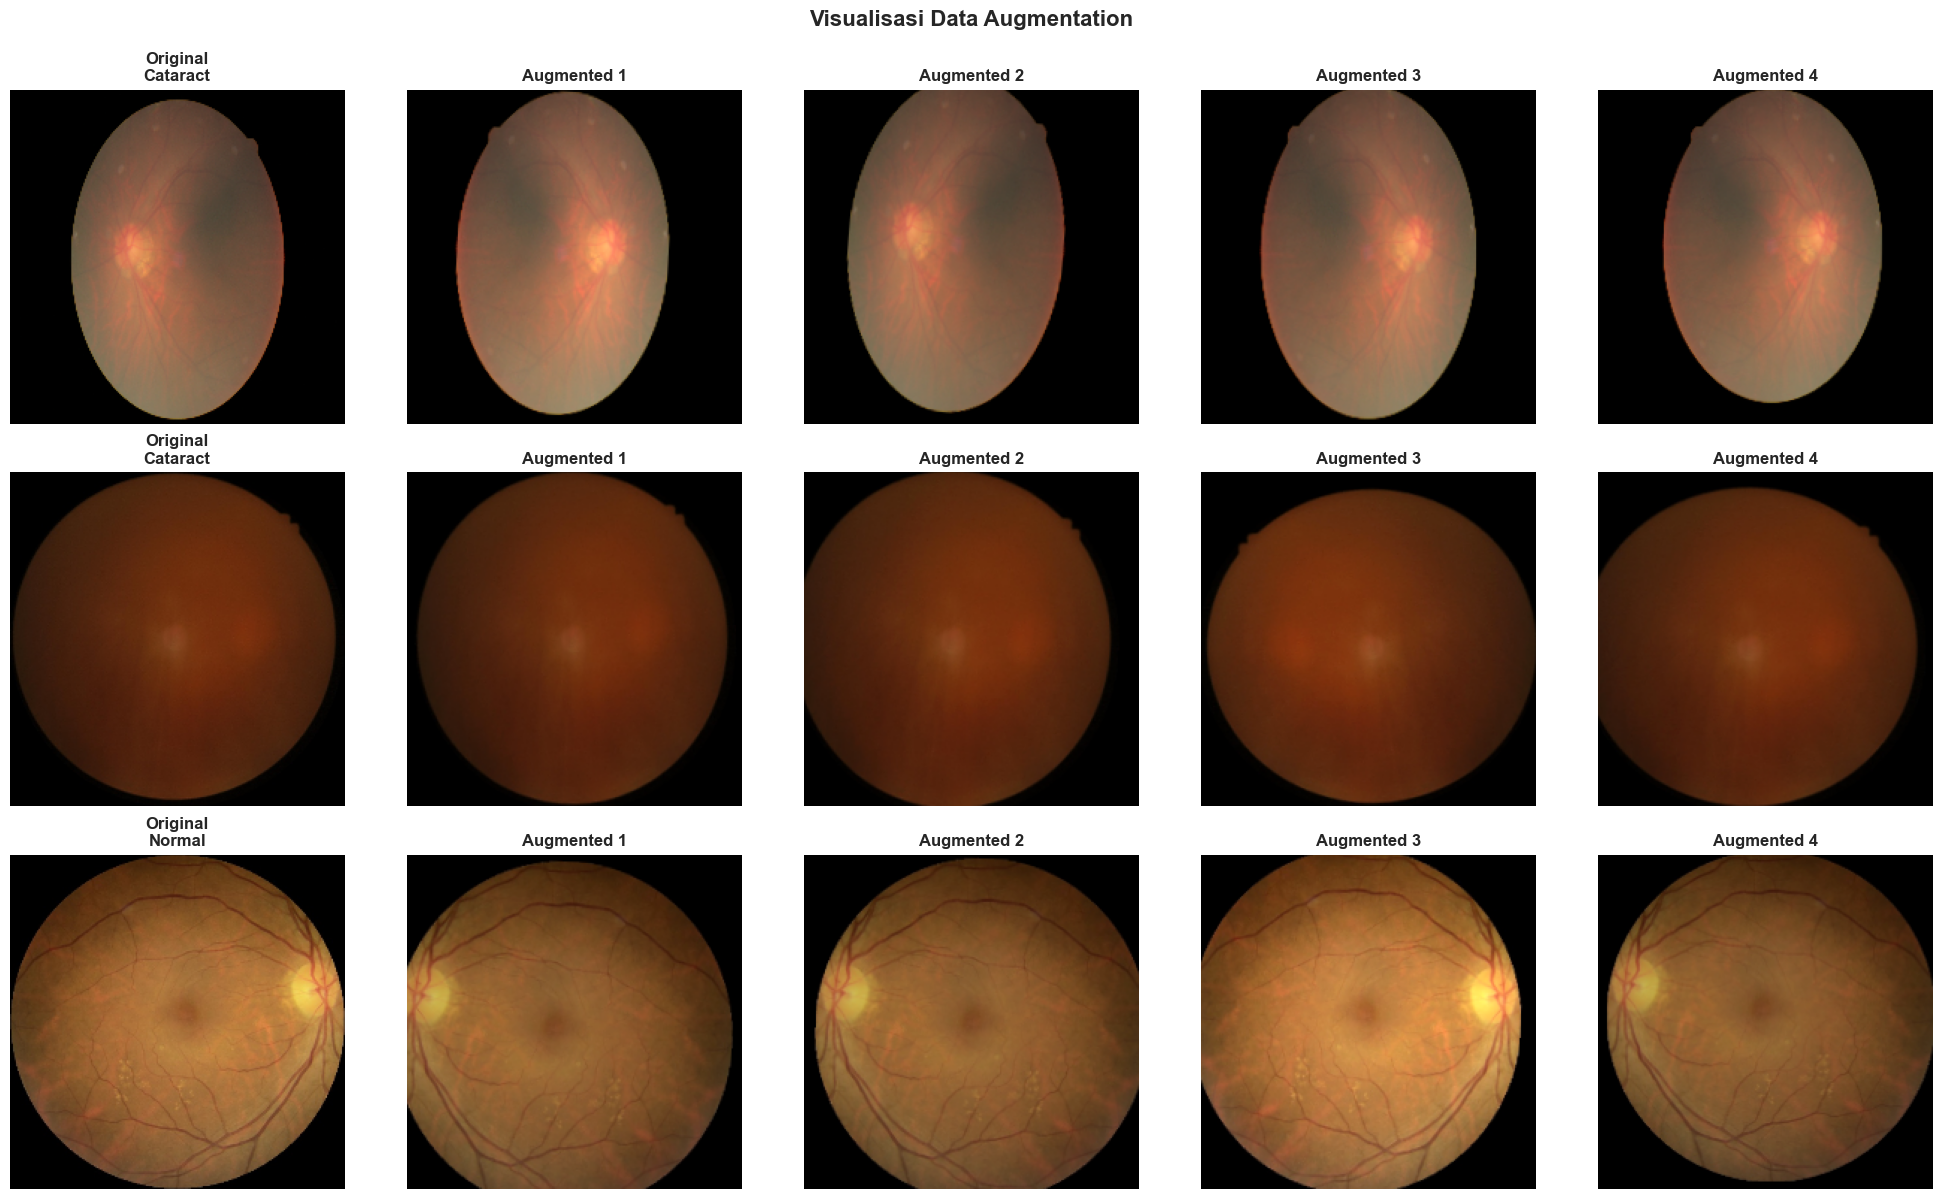


✓ Visualization saved as 'data_augmentation_visualization.png'

SAMPLE BATCH DARI GENERATOR

📊 Generating batch sample visualization...


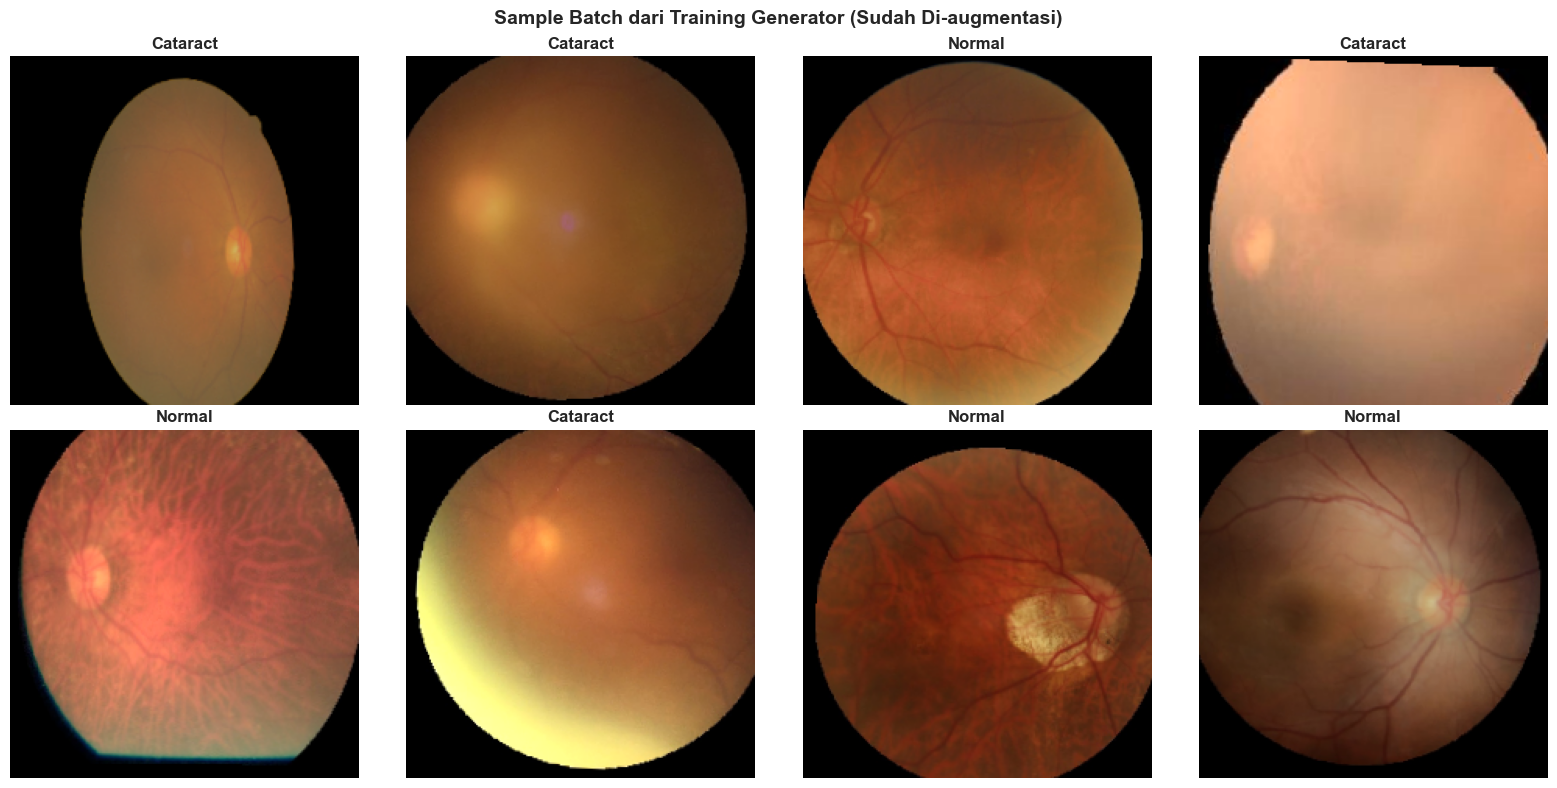


✓ Visualization saved as 'batch_sample_visualization.png'


In [10]:
# ==================== VISUALISASI DATA SETELAH AUGMENTASI ====================
"""
Visualisasi gambar sebelum dan sesudah augmentasi untuk melihat efek preprocessing
"""
print("="*70)
print("VISUALISASI DATA SETELAH AUGMENTASI")
print("="*70)

def visualize_augmentation(train_gen, num_samples=3):
    """
    Visualisasi gambar original vs augmented
    """
    # Get original images
    sample_df = train_df.sample(n=num_samples, random_state=52)
    
    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))
    fig.suptitle('Visualisasi Data Augmentation', fontsize=16, fontweight='bold', y=0.995)
    
    for idx, (_, row) in enumerate(sample_df.iterrows()):
        # Load original image
        img_path = row['filepaths']
        label = row['labels']
        
        # Read original
        original_img = cv2.imread(img_path)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        original_img = cv2.resize(original_img, IMG_SIZE)
        
        # Show original (rescaled only)
        axes[idx, 0].imshow(original_img)
        axes[idx, 0].set_title(f'Original\n{label}', fontweight='bold')
        axes[idx, 0].axis('off')
        
        # Generate augmented versions
        img_array = original_img.reshape((1,) + original_img.shape)
        
        aug_generator = train_datagen.flow(
            img_array,
            batch_size=1
        )
        
        # Show 4 augmented versions
        for i in range(1, 5):
            aug_img = next(aug_generator)[0]
            axes[idx, i].imshow(aug_img)
            axes[idx, i].set_title(f'Augmented {i}', fontweight='bold')
            axes[idx, i].axis('off')
    
    plt.tight_layout()
    plt.savefig('data_augmentation_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Visualization saved as 'data_augmentation_visualization.png'")

# Visualize
print("\n📊 Generating augmentation visualization...")
print("   Showing 3 samples × 5 versions (1 original + 4 augmented)\n")
visualize_augmentation(train_gen, num_samples=3)

# Show batch examples from generator
print("\n" + "="*70)
print("SAMPLE BATCH DARI GENERATOR")
print("="*70)

def visualize_batch(generator, num_images=8):
    """
    Visualisasi satu batch dari generator
    """
    batch_images, batch_labels = next(generator)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Sample Batch dari Training Generator (Sudah Di-augmentasi)', 
                 fontsize=14, fontweight='bold')
    
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            ax.imshow(batch_images[i])
            label_name = 'Normal' if batch_labels[i] > 0.5 else 'Cataract'
            ax.set_title(f'{label_name}', fontweight='bold')
            ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('batch_sample_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Visualization saved as 'batch_sample_visualization.png'")

print("\n📊 Generating batch sample visualization...")
train_gen.reset()
visualize_batch(train_gen, num_images=8)

In [8]:
# ==================== BUILD MOBILENETV2 MODEL ====================

print("="*70)
print("BUILD MODEL - Transfer Learning")
print("="*70)

from tensorflow.keras.applications import MobileNetV2

# Load pre-trained MobileNetV2
print("\nLoading MobileNetV2 (pre-trained on ImageNet)...")

base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# Freeze ALL base layers
base_model.trainable = False

print(f"✓ MobileNetV2 loaded")
print(f"  Total layers: {len(base_model.layers)}")
print(f"  Status: ALL FROZEN")

# Build classifier head
print("\n Building classifier head...")

model = Sequential([
    # Pre-trained base (frozen)
    base_model,
    
    # Global pooling
    GlobalAveragePooling2D(),
    
    # Classifier head (simple & small)
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Cataract_Detection_Model')

print("\n" + "="*70)
print("MODEL ARCHITECTURE")
print("="*70)
model.summary()

# Count parameters
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
total_params = model.count_params()

print("\n" + "="*70)
print("PARAMETER COUNT")
print("="*70)
print(f"Total:        {total_params:,}")
print(f"Trainable:    {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")
print(f"Non-trainable: {total_params - trainable_params:,} ({(total_params - trainable_params)/total_params*100:.2f}%)")
print("="*70)

BUILD MODEL - Transfer Learning

Loading MobileNetV2 (pre-trained on ImageNet)...
✓ MobileNetV2 loaded
  Total layers: 154
  Status: ALL FROZEN

 Building classifier head...

MODEL ARCHITECTURE


Model: "Cataract_Detection_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


PARAMETER COUNT
Total:        2,340,033
Trainable:    82,049 (3.51%)
Non-trainable: 2,257,984 (96.49%)


In [9]:
# ==================== COMPILE MODEL ====================
"""
Compile model dengan optimizer & metrics
"""
print("="*70)
print("COMPILE MODEL")
print("="*70)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("Model compiled!")
print(f"  Optimizer: Adam")
print(f"  Learning Rate: 0.001")
print(f"  Loss: Binary Crossentropy")
print(f"  Metrics: Accuracy, Precision, Recall, AUC")
print("="*70)

COMPILE MODEL
Model compiled!
  Optimizer: Adam
  Learning Rate: 0.001
  Loss: Binary Crossentropy
  Metrics: Accuracy, Precision, Recall, AUC


In [11]:
# ==================== SETUP CALLBACKS ====================
"""
Setup callbacks untuk training
"""
print("="*70)
print("SETUP CALLBACKS")
print("="*70)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    mode='max',
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_cataract_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks = [early_stop, reduce_lr, checkpoint]

print("Callbacks configured:")
print("  • EarlyStopping: patience=10, monitor=val_accuracy")
print("  • ReduceLR: patience=5, factor=0.5, monitor=val_accuracy")
print("  • ModelCheckpoint: save best val_accuracy")
print("="*70)

SETUP CALLBACKS
Callbacks configured:
  • EarlyStopping: patience=10, monitor=val_accuracy
  • ReduceLR: patience=5, factor=0.5, monitor=val_accuracy
  • ModelCheckpoint: save best val_accuracy


START TRAINING
Strategy: Train classifier head only (base frozen)
Epochs: 25 (with early stopping)
Learning Rate: 0.001

Training started...
----------------------------------------------------------------------
Epoch 1/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7586 - auc: 0.8274 - loss: 0.4814 - precision: 0.7628 - recall: 0.7566
Epoch 1: val_accuracy improved from -inf to 0.92429, saving model to best_cataract_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.7631 - auc: 0.8321 - loss: 0.4742 - precision: 0.7672 - recall: 0.7613 - val_accuracy: 0.9243 - val_auc: 0.9786 - val_loss: 0.2037 - val_precision: 0.9152 - val_recall: 0.9379 - learning_rate: 0.0010
Epoch 2/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9380 - auc: 0.9808 - loss: 0.1651 - precision: 0.9513 - recall: 0.9263
Epoch 2: val_accuracy improved from 0.92429 to 0.94006, saving model to best_cataract_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9384 - auc: 0.9810 - 

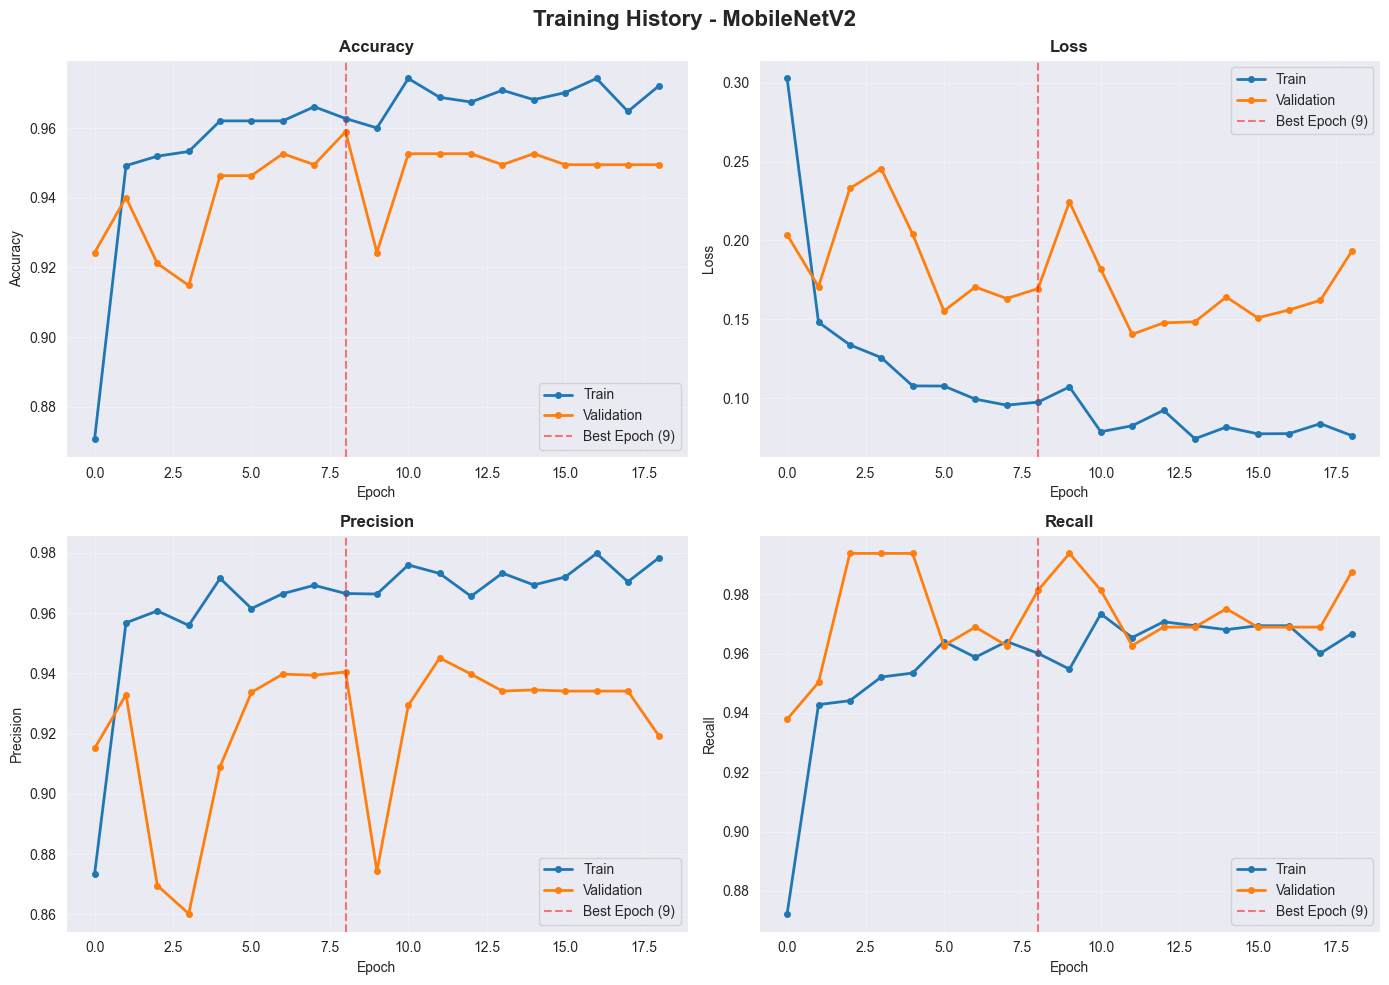


✓ Training history saved to 'training_history.pkl'


In [12]:
# ==================== CELL 9: TRAINING MODEL ====================

print("="*70)
print("START TRAINING")
print("="*70)
print("Strategy: Train classifier head only (base frozen)")
print("Epochs: 25 (with early stopping)")
print("Learning Rate: 0.001")
print("="*70)

print("\nTraining started...")
print("-"*70)

start_time = time.time()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "="*70)
print("✓ TRAINING COMPLETE!")
print("="*70)
print(f"Training time: {training_time/60:.2f} minutes")

# Get best results
best_epoch = np.argmax(history.history['val_accuracy'])
best_val_acc = max(history.history['val_accuracy'])
best_train_acc = history.history['accuracy'][best_epoch]
best_val_loss = history.history['val_loss'][best_epoch]
best_train_loss = history.history['loss'][best_epoch]

print(f"\nBEST RESULTS:")
print("="*70)
print(f"Best Epoch:        {best_epoch + 1}")
print(f"Train Accuracy:    {best_train_acc:.4f} ({best_train_acc*100:.2f}%)")
print(f"Val Accuracy:      {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Train Loss:        {best_train_loss:.4f}")
print(f"Val Loss:          {best_val_loss:.4f}")

# Check overfitting
gap = abs(best_train_acc - best_val_acc)
print(f"\n📏 Train-Val Gap:   {gap:.4f} ({gap*100:.2f}%)")

if gap < 0.05:
    print("EXCELLENT! Gap < 5% → No overfitting!")
elif gap < 0.10:
    print("✓ GOOD! Gap 5-10% → Slight overfitting, acceptable")
elif gap < 0.15:
    print("⚠ OK. Gap 10-15% → Moderate overfitting")
else:
    print("WARNING! Gap > 15% → Overfitting detected")

print("="*70)

# Plot training history
print("\n📈 Plotting training history...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History - MobileNetV2', 
             fontsize=16, fontweight='bold')

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', 
                linewidth=2, marker='o', markersize=4)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation', 
                linewidth=2, marker='o', markersize=4)
axes[0, 0].axvline(x=best_epoch, color='red', linestyle='--', 
                   alpha=0.5, label=f'Best Epoch ({best_epoch+1})')
axes[0, 0].set_title('Accuracy', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train', 
                linewidth=2, marker='o', markersize=4)
axes[0, 1].plot(history.history['val_loss'], label='Validation', 
                linewidth=2, marker='o', markersize=4)
axes[0, 1].axvline(x=best_epoch, color='red', linestyle='--', 
                   alpha=0.5, label=f'Best Epoch ({best_epoch+1})')
axes[0, 1].set_title('Loss', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train', 
                linewidth=2, marker='o', markersize=4)
axes[1, 0].plot(history.history['val_precision'], label='Validation', 
                linewidth=2, marker='o', markersize=4)
axes[1, 0].axvline(x=best_epoch, color='red', linestyle='--', 
                   alpha=0.5, label=f'Best Epoch ({best_epoch+1})')
axes[1, 0].set_title('Precision', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train', 
                linewidth=2, marker='o', markersize=4)
axes[1, 1].plot(history.history['val_recall'], label='Validation', 
                linewidth=2, marker='o', markersize=4)
axes[1, 1].axvline(x=best_epoch, color='red', linestyle='--', 
                   alpha=0.5, label=f'Best Epoch ({best_epoch+1})')
axes[1, 1].set_title('Recall', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Save history for later analysis
import pickle
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("\n✓ Training history saved to 'training_history.pkl'")

FINAL EVALUATION - TEST SET

Loading best model...
✓ Best model loaded (from epoch 9)

Running evaluation on test set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9513 - auc: 0.9954 - loss: 0.1352 - precision: 0.9141 - recall: 1.0000

TEST SET RESULTS
Test Accuracy:  0.9432 (94.32%)
Test Precision: 0.8994 (89.94%)
Test Recall:    1.0000 (100.00%)
Test AUC:       0.9952
Test Loss:      0.1497
Test F1-Score:  0.9471 (94.71%)

 Getting predictions on test set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
✓ Predictions obtained (317 samples)

CONFUSION MATRIX

                 Predicted
              Cataract  Normal
Actual Cataract   138       18
       Normal       0      161

True Positives (TP):  161 (Normal correctly identified)
True Negatives (TN):  138 (Cataract correctly identified)
False Positives (FP): 18 (Cataract predicted as Normal)
False Negatives (FN): 0 (Normal predicted as Cataract)

Sensitivity (Recall): 1.0000 (100.00%)
Specificity:          0.8846 (88.46%)

💡 Medical C

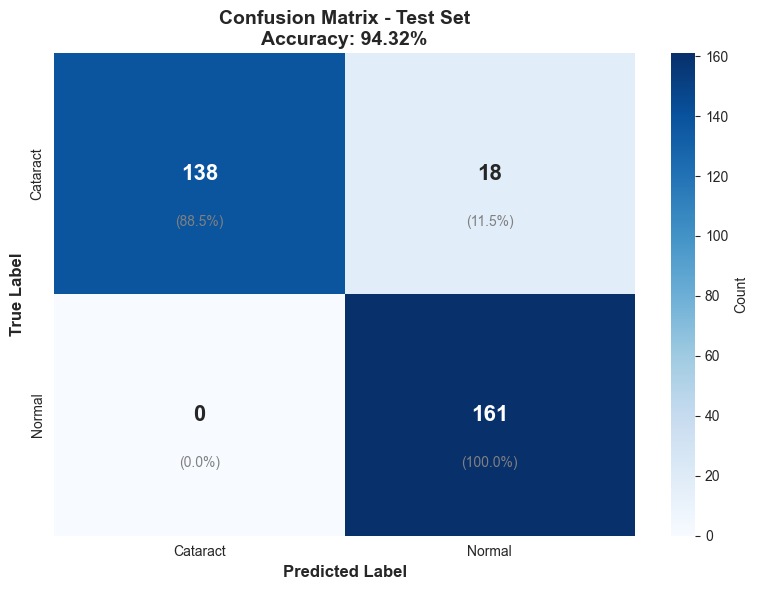


FINAL SUMMARY
✅ Test Accuracy: 94.32%
✅ Validation Accuracy: 95.90%
✅ Train Accuracy: 96.28%

Generalization Check:
  Val - Test gap: 1.58%
  ✅ Excellent! Model generalizes well!

✓ Evaluation complete!
✓ Files saved:
  • best_cataract_model.keras
  • training_history.png
  • training_history.pkl
  • confusion_matrix_test.png


In [13]:
# ==================== CELL 10: EVALUATE ON TEST SET ====================
"""
Evaluasi final pada test set (data yang belum pernah dilihat)
"""
print("="*70)
print("FINAL EVALUATION - TEST SET")
print("="*70)

# Load best model
print("\nLoading best model...")
best_model = keras.models.load_model('best_cataract_model.keras')
print("✓ Best model loaded (from epoch {})".format(best_epoch + 1))

# Evaluate on test set
print("\n" + "="*70)
print("Running evaluation on test set...")
print("="*70)

test_results = best_model.evaluate(test_gen, verbose=1)

test_loss = test_results[0]
test_acc = test_results[1]
test_prec = test_results[2]
test_rec = test_results[3]
test_auc = test_results[4]

print("\n" + "="*70)
print("TEST SET RESULTS")
print("="*70)
print(f"Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Precision: {test_prec:.4f} ({test_prec*100:.2f}%)")
print(f"Test Recall:    {test_rec:.4f} ({test_rec*100:.2f}%)")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test Loss:      {test_loss:.4f}")

# Calculate F1-Score
f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec)
print(f"Test F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

print("="*70)

# Get predictions
print("\n Getting predictions on test set...")
test_gen.reset()
y_pred_prob = best_model.predict(test_gen, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

print(f"✓ Predictions obtained ({len(y_pred)} samples)")

# Confusion Matrix
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(y_true, y_pred)
class_names = ['Cataract', 'Normal']

print("\n                 Predicted")
print("              Cataract  Normal")
print(f"Actual Cataract   {cm[0,0]:3d}      {cm[0,1]:3d}")
print(f"       Normal     {cm[1,0]:3d}      {cm[1,1]:3d}")

tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Positives (TP):  {tp} (Normal correctly identified)")
print(f"True Negatives (TN):  {tn} (Cataract correctly identified)")
print(f"False Positives (FP): {fp} (Cataract predicted as Normal)")
print(f"False Negatives (FN): {fn} (Normal predicted as Cataract)")

# Additional metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nSensitivity (Recall): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"Specificity:          {specificity:.4f} ({specificity*100:.2f}%)")

print("\n💡 Medical Context:")
print(f"  • Sensitivity: Kemampuan detect Normal correctly")
print(f"  • Specificity: Kemampuan detect Cataract correctly")
print("="*70)

# Classification Report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Visualize Confusion Matrix
print("\nPlotting confusion matrix...")

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=ax, 
            annot_kws={'size': 16, 'weight': 'bold'})

ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
ax.set_ylabel('True Label', fontweight='bold', fontsize=12)
ax.set_title(f'Confusion Matrix - Test Set\nAccuracy: {test_acc*100:.2f}%', 
             fontweight='bold', fontsize=14)

# Add percentages
for i in range(2):
    for j in range(2):
        total = cm[i].sum()
        percentage = cm[i, j] / total * 100
        ax.text(j+0.5, i+0.7, f'({percentage:.1f}%)', 
               ha='center', va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")
print(f"✅ Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"✅ Train Accuracy: {best_train_acc*100:.2f}%")
print(f"\nGeneralization Check:")
print(f"  Val - Test gap: {abs(best_val_acc - test_acc)*100:.2f}%")
if abs(best_val_acc - test_acc) < 0.03:
    print("  ✅ Excellent! Model generalizes well!")
elif abs(best_val_acc - test_acc) < 0.05:
    print("  ✓ Good! Model generalizes well!")
else:
    print("  ⚠ Gap > 5%, check for issues")
print("="*70)

print("\n✓ Evaluation complete!")
print("✓ Files saved:")
print("  • best_cataract_model.keras")
print("  • training_history.png")
print("  • training_history.pkl")
print("  • confusion_matrix_test.png")